# m12
Se cree que el parametro $m_{12}$ podria ser fine tunned, existen valores conocidos en rangos muy especificos;
se desea conocer si en distintas variaciones de 
- $m_\phi; m_A=m_{H^\pm}$
- $\lambda_7=0$ y $\lambda_6=10^{-\{1,2,3,4\}}$
que rangos o zonas importantes del espacio parametrico el parametro $m_{12}$ aporta estabilidad

## recomendaciones
Se puede observar que a partir de conocer $\vec m$ y $m_{12}$ esto corresponde a una combinacion: $\vec \lambda$; se ha observado que la perturbatividad es la primera en perderse, observandose con valores de $\lambda$ grandes; comunmente estos deben de encontrarse $|\lambda|<16\pi$, sin embargo dado que esta condicion proviene de expresiones de autovalores, la cantidad puede ser menor sin embargo escalara proporcionalmente a alguna potencial de $\lambda$ por tanto acaba siendo util observar como una metrica de perturbatividad a una combinacion lineal de potencias de $\lambda$


## Parametros de los ejemplos
 mh mH mA mHp sin(beta-alpha) lambda_6 lambda_7 m_12^2 tan_beta yukawas_type output_filename
mH -> 	mphi = [200, 240]
	mA = 300
	sin(beta-alpha) = 1
	lambda6 = 1e-4
	lambda7 = 0
	tan_beta = 10000000 --> beta = 1.570796226794897 (Pi/2 - 1e-7)
	alpha = 1e-7

In [8]:
#obj 0: llamada simple y separar outputs
from lib.oracle import run_oracle, safe_run_oracle
from lib.explorer import explore_points, explore_points_parallel
from lib.utils import estimate_exploration_time, expand_parameter_space
import numpy as np
import matplotlib.pyplot as plt

# parametros globales a utilizar
lambda6 = 0.1
lambda7 = 0.0
alpha = 1e-7
beta  = 1.570796226794897

# wrapper para valores fijos
def physpoint(mphi : np.float64, m12_2 : np.float64, mA : np.float64 = 300.0):
    # Parámetros fijos

    # m_phi, mA, alpha, beta, lambda6, lambda7, m12^2
    return safe_run_oracle([mphi, mA, alpha, beta, lambda6, lambda7, m12_2])

# objetivo 1: obtener una metrica lineal de lambdas a forma de una funcion de perdida

def loss(mphi : np.float64, m12_2 : np.float64, mA : np.float64 = 300.0):
    output = physpoint(mphi, m12_2, mA)
    return np.abs(output['lambda1']) + np.abs(output['lambda2']) + np.abs(output['lambda3']) + np.abs(output['lambda4']) + + np.abs(output['lambda5'])


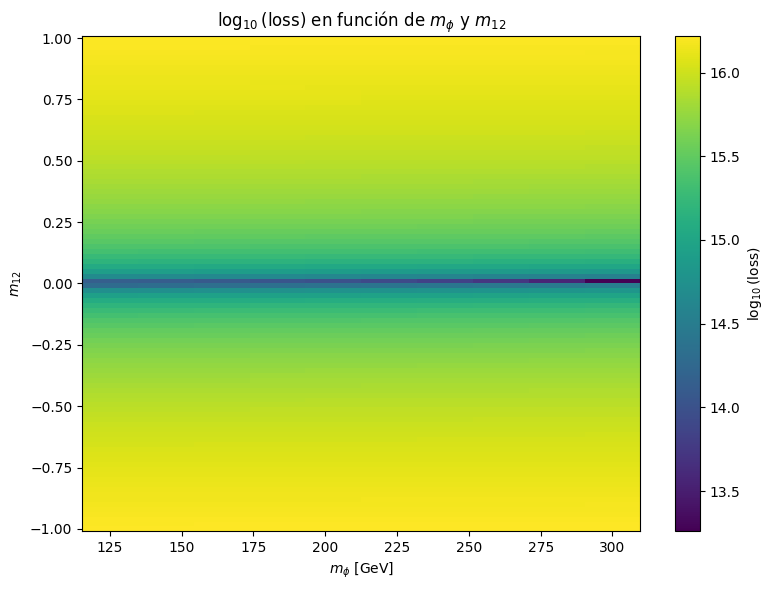

In [9]:
# Objetivo 2:
# mapa de color tipo log(loss), ejes horizontal, vertical: mphi, m12


# Definir rejilla
n_phi  = 10
n_m12  = 100
mphi_v = np.linspace(125.1, 300.0, n_phi)
m12_v  = np.linspace(-1.0,  1.0,   n_m12)

# Matriz de pérdidas
L = np.empty((n_m12, n_phi))
L[:] = np.nan

for i, m12 in enumerate(m12_v):
    for j, mphi in enumerate(mphi_v):
        val = loss(mphi, m12)
        L[i,j] = val
        # try:
        #     val = loss(mphi, m12)
        # except Exception:
        #     L[i,j] = np.nan
        # else:
        #     L[i,j] = val

# Tomamos log y enmascaramos valores demasiado grandes (por ej. >1e3)
with np.errstate(divide='ignore'):
    Z = np.log10(L)
#Z[L > 1e3] = np.nan


# # Plot
plt.figure(figsize=(8,6))
# pcolormesh requiere mallas “extendidas”
X, Y = np.meshgrid(mphi_v, m12_v)
pcm = plt.pcolormesh(X, Y, Z, shading='auto')
plt.xlabel(r'$m_\phi$ [GeV]')
plt.ylabel(r'$m_{12}$')
plt.title(r'$\log_{10}(\mathrm{loss})$ en función de $m_\phi$ y $m_{12}$')
plt.colorbar(pcm, label=r'$\log_{10}(\mathrm{loss})$')
plt.tight_layout()
plt.show()


## ajuste fino y cercano a 0 de $m_{12}^2$

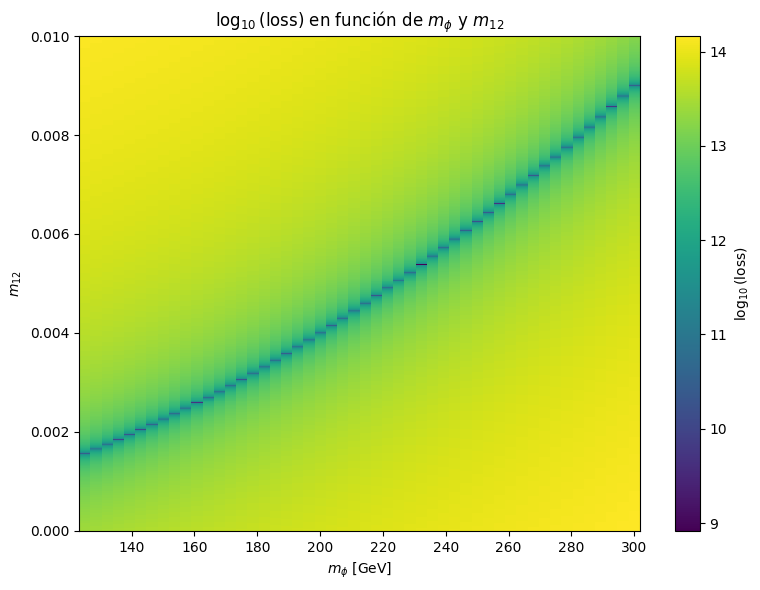

In [10]:
# Definir rejilla
n_phi  = 50
n_m12  = 500
mphi_v = np.linspace(125.1, 300.0, n_phi)
m12_v  = np.linspace(0,  0.01,   n_m12)

# Matriz de pérdidas
L = np.empty((n_m12, n_phi))
L[:] = np.nan

for i, m12 in enumerate(m12_v):
    for j, mphi in enumerate(mphi_v):
        val = loss(mphi, m12)
        L[i,j] = val

# Tomamos log y enmascaramos valores demasiado grandes (por ej. >1e3)
with np.errstate(divide='ignore'):
    Z = np.log10(L)


# # Plot
plt.figure(figsize=(8,6))
X, Y = np.meshgrid(mphi_v, m12_v)
pcm = plt.pcolormesh(X, Y, Z, shading='auto')
plt.xlabel(r'$m_\phi$ [GeV]')
plt.ylabel(r'$m_{12}$')
plt.title(r'$\log_{10}(\mathrm{loss})$ en función de $m_\phi$ y $m_{12}$')
plt.colorbar(pcm, label=r'$\log_{10}(\mathrm{loss})$')
plt.tight_layout()
plt.show()


## Ajuste polinomial
Un experimento para conseguir una ecuacion del plano

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from lib.oracle import safe_run_oracle
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D


# Definición de rejillas
n_phi = 10
n_m12 = 50
n_mA  = 10

mphi_vals = np.linspace(125.1, 300.0, n_phi)
m12_vals  = np.linspace(0,   1.0,   n_m12)
mA_vals   = np.linspace(200.0,  400.0, n_mA)

# Matrices para almacenar mA* y la pérdida mínima
MA_min = np.empty((n_m12, n_phi))
Loss_min = np.empty_like(MA_min)

# Búsqueda del mínimo en mA para cada (mφ, m12)
for i, m12 in enumerate(m12_vals):
    for j, mphi in enumerate(mphi_vals):
        # calcular pérdidas para cada mA
        vals = []
        for mA in mA_vals:
            vals.append(loss(mphi, m12, mA))

        vals = np.array(vals)
        idx = np.nanargmin(vals)
        MA_min[i, j] = mA_vals[idx]
        Loss_min[i, j] = vals[idx]

# Ajuste polinomial a grado 3
X = np.vstack([
    np.repeat(mphi_vals, n_m12),
    np.tile(m12_vals, n_phi)
]).T  # Forma (n_phi*n_m12, 2)
y = MA_min.ravel()

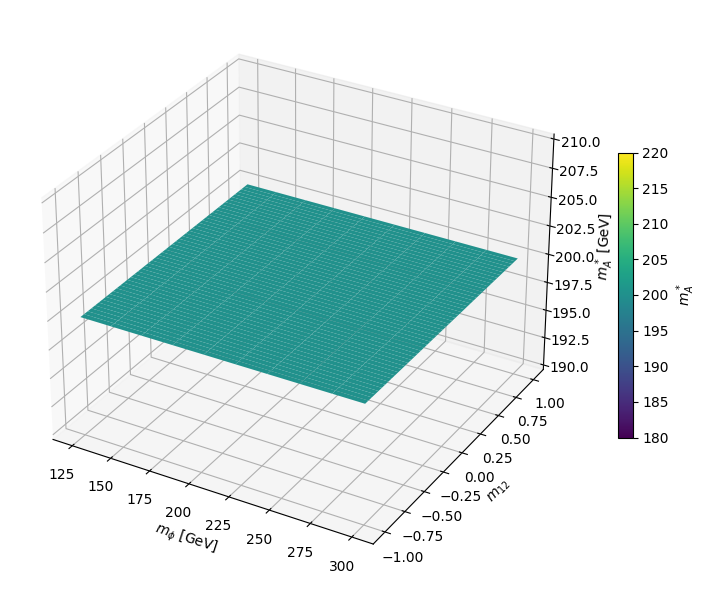

Modelo ajustado: mA* =
  +0.000e+00 * 1
  +0.000e+00 * mphi
  +0.000e+00 * m12
  +0.000e+00 * mphi^2
  +0.000e+00 * mphi m12
  +0.000e+00 * m12^2
  +0.000e+00 * mphi^3
  +0.000e+00 * mphi^2 m12
  +0.000e+00 * mphi m12^2
  +0.000e+00 * m12^3
  +2.000e+02  (intercept)


In [ ]:


poly = PolynomialFeatures(degree=3, include_bias=True)
Xp   = poly.fit_transform(X)
reg  = LinearRegression().fit(Xp, y)

# Visualización 3D de la superficie mA*(mφ, m12)
fig = plt.figure(figsize=(8,6))
ax  = fig.add_subplot(111, projection='3d')
Phi, M12 = np.meshgrid(mphi_vals, m12_vals)
surf = ax.plot_surface(Phi, M12, MA_min, cmap='viridis', edgecolor='none')
ax.set_xlabel(r'$m_\phi$ [GeV]')
ax.set_ylabel(r'$m_{12}$')
ax.set_zlabel(r'$m_A^*$ [GeV]')
fig.colorbar(surf, ax=ax, shrink=0.5, label=r'$m_A^*$')
plt.tight_layout()
plt.show()

# Imprimir coeficientes del polinomio ajustado
terms     = poly.get_feature_names_out(['mphi','m12'])
coefs     = reg.coef_
intercept = reg.intercept_

print("Modelo ajustado: mA* =")
for t, c in zip(terms, coefs):
    print(f"  {c:+.3e} * {t}")
print(f"  {intercept:+.3e}  (intercept)")
